
# Assignment 2 — Portfolio Optimization 
Long/short Monte Carlo, efficient frontier (closed-form), and stochastic programming via Sample Average Approximation (SAA).  
**This notebook is self-contained and includes built-in scenarios.**




- Figures in `results/figs/`
  - Efficient frontier & random portfolios (shorts-OK)
  - True vs SAA frontier (overlay)
  - Long-only cloud and Shorts-OK cloud (like the sample paper)
- CSVs in `results/out/`
  - Frontier points (`*_frontier.csv`) and SAA (`*_frontier_saa.csv`)
  - Random portfolio clouds (`*_cloud.csv`)
  - Three example portfolios along the frontier (`*_example_portfolios.csv`)


In [1]:

# Imports & configuration (no seaborn)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

# Output folders
OUTDIR = Path('results')
(OUTDIR / 'figs').mkdir(parents=True, exist_ok=True)
(OUTDIR / 'out').mkdir(parents=True, exist_ok=True)

# Reproducibility & knobs
GAMMAS   = np.logspace(-2, 2, 50)  # risk-aversion sweep for the frontier
MC_SIZE  = 5000                    # random portfolios per policy for clouds
SAA_SIMS = 10_000                  # simulations for SAA frontier

SEED_LONG  = 2025
SEED_SHORT = 2026
SEED_SAA   = 2027


In [ ]:

# Utilities

# Ensure the covariance matrix is positive definite to prevent simulation or optimization failures caused by non-SPD matrices.
def nearest_spd(Sigma: np.ndarray, jitter_start: float = 1e-10) -> np.ndarray:
    """Return a symmetric positive-definite matrix close to Sigma (adds tiny jitter if needed)."""
    Sigma = 0.5 * (Sigma + Sigma.T)
    jitter = jitter_start
    while True:
        try:
            np.linalg.cholesky(Sigma + jitter * np.eye(Sigma.shape[0]))
            return Sigma + jitter * np.eye(Sigma.shape[0])
        except np.linalg.LinAlgError:
            jitter *= 10.0
            if jitter > 1e-2:
                return Sigma + 1e-2 * np.eye(Sigma.shape[0])

# Build a valid covariance matrix from standard deviations and correlations, ensuring it is positive definite for stable simulations.
def build_covariance(sigmas: np.ndarray, corr: np.ndarray) -> np.ndarray:
    D = np.diag(sigmas)
    return nearest_spd(D @ corr @ D)

# Compute mean–variance optimal portfolio weights with risk aversion gamma and the constraint that all weights sum to one.

def mv_optimal_weights(mu: np.ndarray, Sigma: np.ndarray, gamma: float) -> np.ndarray:
    """Shorts-OK mean–variance optimizer with equality constraint 1ᵀw = 1 (closed-form KKT)."""
    n = len(mu)
    mu = mu.reshape(-1, 1)
    ones = np.ones((n, 1))
    top = np.concatenate([gamma * Sigma, ones], axis=1)
    bottom = np.concatenate([ones.T, np.zeros((1, 1))], axis=1)
    KKT = np.concatenate([top, bottom], axis=0)
    rhs = np.concatenate([mu, np.array([[1.0]])], axis=0)
    sol = np.linalg.solve(KKT, rhs)
    return sol[:-1, :].flatten()

def simulate_returns(mu: np.ndarray, Sigma: np.ndarray, n_sims: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mean=mu, cov=Sigma, size=n_sims)

def sample_weights_long_only(n: int, n_assets: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.dirichlet(alpha=np.ones(n_assets), size=n)  # w >= 0, sum=1

def sample_weights_shorts_ok(n: int, n_assets: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=(n, n_assets))
    return (Z.T / Z.sum(axis=1)).T  # weights can be negative, sum=1

def portfolio_stats(W: np.ndarray, mu: np.ndarray, Sigma: np.ndarray):
    p_mu = W @ mu
    p_var = np.einsum('ij,jk,ik->i', W, Sigma, W)
    return p_mu, np.sqrt(p_var)


# Generate the efficient frontier by computing return, risk, and optimal weights for each risk aversion level gamma.

def frontier_curve(mu: np.ndarray, Sigma: np.ndarray, gammas: np.ndarray) -> pd.DataFrame:
    rows = []
    for g in gammas:
        w = mv_optimal_weights(mu, Sigma, g)
        rows.append({
            "gamma": float(g),
            "ret":   float(mu @ w),
            "stdev": float(np.sqrt(w @ Sigma @ w)),
            "weights": w
        })
    return pd.DataFrame(rows)

def frontier_saa(mu: np.ndarray, Sigma: np.ndarray, gammas: np.ndarray, n_sims: int, seed: int) -> pd.DataFrame:
    sims = simulate_returns(mu, Sigma, n_sims, seed)
    mu_hat = sims.mean(axis=0)
    Sigma_hat = np.cov(sims, rowvar=False)
    Sigma_hat = nearest_spd(Sigma_hat)
    return frontier_curve(mu_hat, Sigma_hat, gammas)

def plot_cloud_and_frontier(cloud_df, fr_df, title, savepath=None):
    plt.figure()
    plt.scatter(cloud_df["stdev"], cloud_df["ret"], s=6, alpha=0.25, label="Random portfolios")
    plt.plot(fr_df["stdev"], fr_df["ret"], linewidth=2, label="Efficient frontier")
    plt.xlabel("Portfolio standard deviation")
    plt.ylabel("Expected return")
    plt.title(title)
    plt.legend()
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

def plot_true_vs_saa(fr_true, fr_saa, title, savepath=None):
    plt.figure()
    plt.plot(fr_true["stdev"], fr_true["ret"], linewidth=2, label="Frontier (true μ, Σ)")
    plt.plot(fr_saa["stdev"], fr_saa["ret"], linewidth=2, linestyle="--", label="Frontier (SAA μ̂, Σ̂)")
    plt.xlabel("Portfolio standard deviation")
    plt.ylabel("Expected return")
    plt.title(title)
    plt.legend()
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()



## Built-in scenarios

# Scenario 1: AI-infra balanced
# Scenario 2: Macro diversified


In [3]:

SCENARIOS = [
    # Scenario 1: AI-infra balanced
    {
        "name": "AI_Infra_Balanced",
        "tickers": ["AI_EQUITY", "US_CORE_BOND", "REIT", "GOLD"],
        "mu":  [0.14, 0.05, 0.08, 0.04],     # expected annual returns
        "sig": [0.30, 0.06, 0.16, 0.12],     # annual volatilities
        "corr": [
            [1.00, -0.10, 0.30, 0.10],
            [-0.10, 1.00, -0.05, -0.20],
            [0.30, -0.05, 1.00, 0.20],
            [0.10, -0.20, 0.20, 1.00],
        ],
    },
    # Scenario 2: Macro diversified
    {
        "name": "Macro_Diversified",
        "tickers": ["US_EQ", "INTL_EQ", "EM_EQ", "TIPS", "COMMOD"],
        "mu":  [0.11, 0.09, 0.10, 0.045, 0.07],
        "sig": [0.18, 0.20, 0.24, 0.06,   0.15],
        "corr": [
            [1.00, 0.70, 0.65, -0.20, 0.25],
            [0.70, 1.00, 0.75, -0.15, 0.30],
            [0.65, 0.75, 1.00, -0.10, 0.35],
            [-0.20,-0.15,-0.10, 1.00,-0.20],
            [0.25, 0.30, 0.35, -0.20, 1.00],
        ],
    },
]

# Basic validation
for sc in SCENARIOS:
    mu  = np.asarray(sc["mu"], dtype=float)
    sig = np.asarray(sc["sig"], dtype=float)
    corr= np.asarray(sc["corr"], dtype=float)
    assert mu.ndim==1 and sig.ndim==1 and corr.ndim==2, "mu/sig must be 1D, corr 2D"
    assert len(sig)==len(mu) and corr.shape==(len(mu),len(mu)), f"dimension mismatch in {sc['name']}"
print(f"Loaded {len(SCENARIOS)} scenario(s).")


Loaded 2 scenario(s).



## Run analysis for all scenarios
This cell generates clouds, frontiers, and figures + CSVs for each scenario.


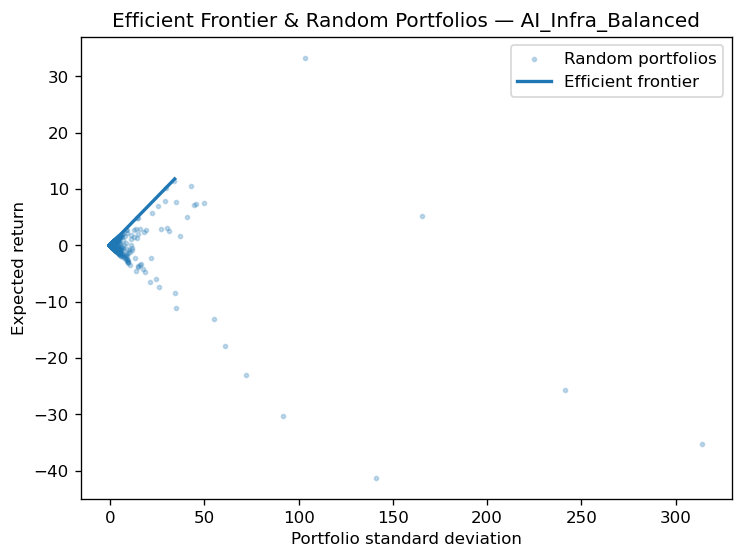

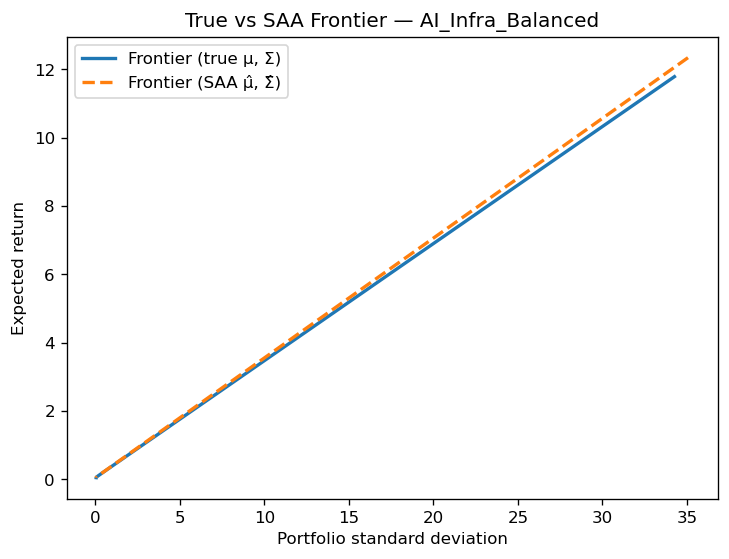

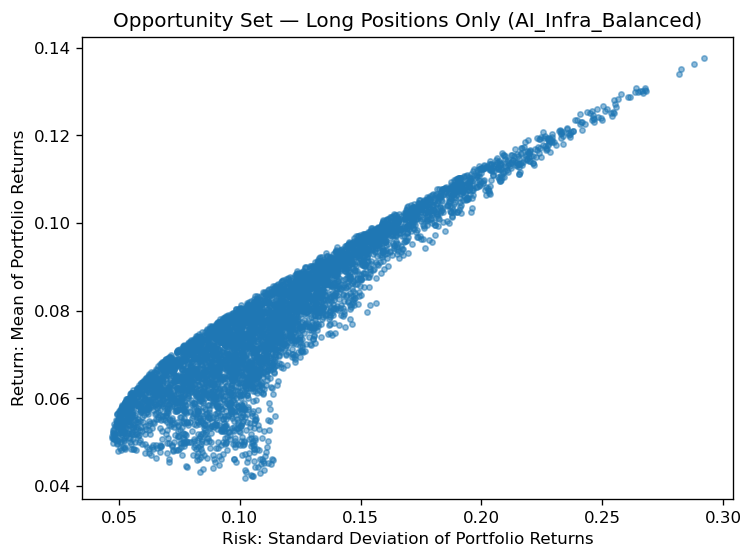

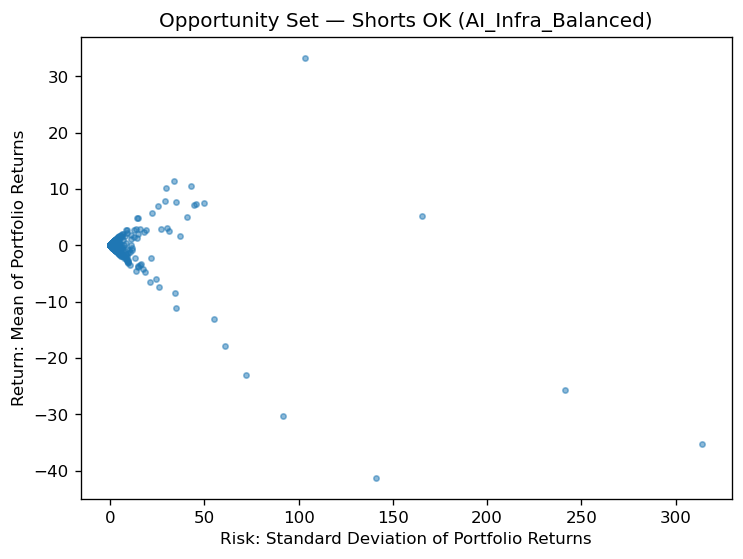

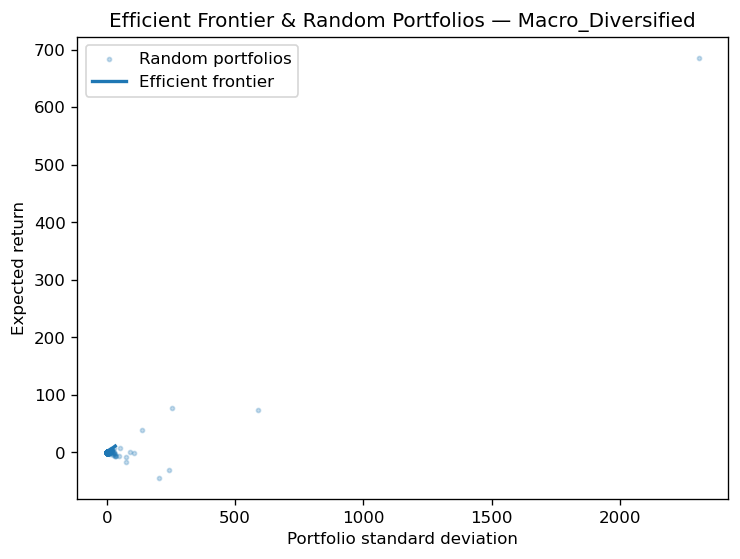

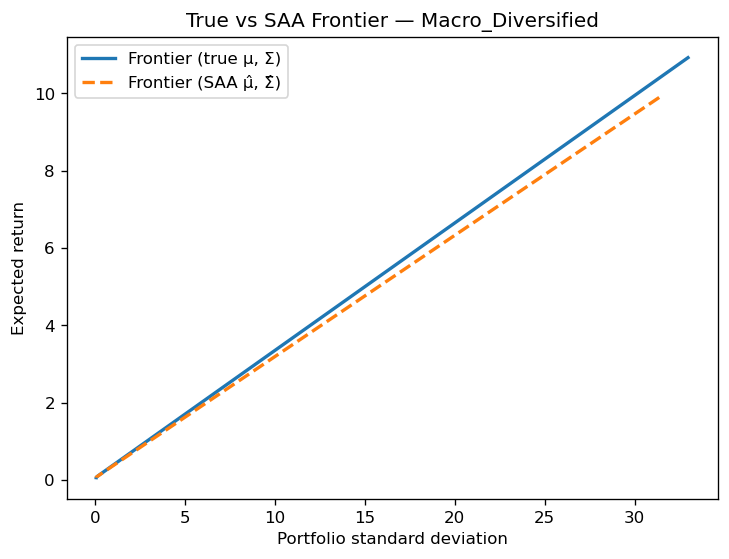

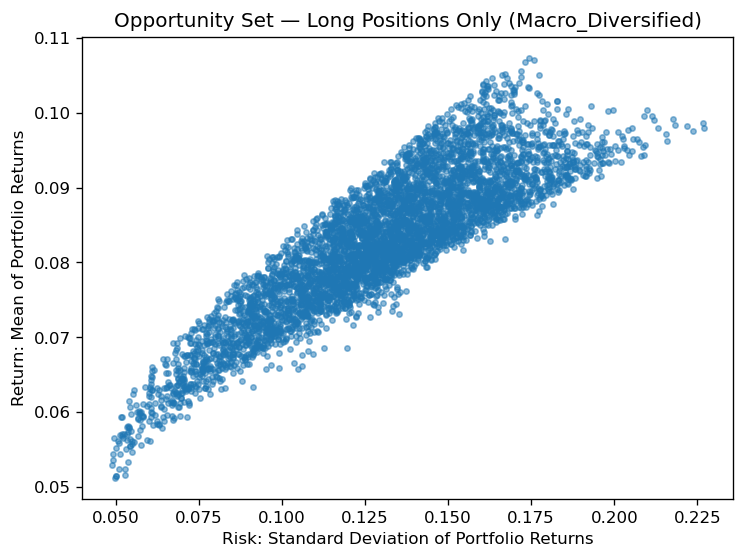

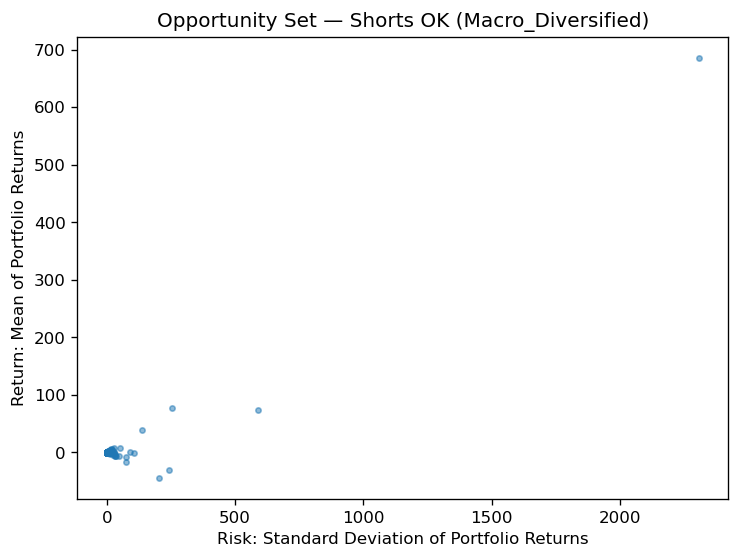

,name,tickers,n_assets,frontier_csv,picks_csv,cloud_csv
0,AI_Infra_Balanced,"[AI_EQUITY, US_CORE_BOND, REIT, GOLD]",4,results/out/AI_Infra_Balanced_frontier.csv,results/out/AI_Infra_Balanced_example_portfoli...,results/out/AI_Infra_Balanced_cloud.csv
1,Macro_Diversified,"[US_EQ, INTL_EQ, EM_EQ, TIPS, COMMOD]",5,results/out/Macro_Diversified_frontier.csv,results/out/Macro_Diversified_example_portfoli...,results/out/Macro_Diversified_cloud.csv


In [4]:

summaries = []

for sc in SCENARIOS:
    name = sc["name"]
    tickers = sc.get("tickers", [f"A{i+1}" for i in range(len(sc["mu"]))])

    mu  = np.asarray(sc["mu"], dtype=float)
    sig = np.asarray(sc["sig"], dtype=float)
    corr= np.asarray(sc["corr"], dtype=float)
    Sigma = build_covariance(sig, corr)

    # Monte Carlo clouds
    W_long  = sample_weights_long_only(MC_SIZE, len(mu), SEED_LONG)
    W_short = sample_weights_shorts_ok(MC_SIZE, len(mu), SEED_SHORT)
    mu_long, sd_long   = portfolio_stats(W_long,  mu, Sigma)
    mu_short, sd_short = portfolio_stats(W_short, mu, Sigma)

    cloud = pd.DataFrame({
        "ret":   np.concatenate([mu_long, mu_short]),
        "stdev": np.concatenate([sd_long, sd_short]),
        "strategy": np.array(["long_only"]*MC_SIZE + ["shorts_ok"]*MC_SIZE)
    })

    # Efficient frontiers (shorts-OK): True vs SAA
    fr_true = frontier_curve(mu, Sigma, GAMMAS); fr_true["name"]=name
    fr_saa  = frontier_saa(mu, Sigma, GAMMAS, SAA_SIMS, SEED_SAA); fr_saa["name"]=name

    # Example portfolios (low/mid/high risk from True frontier)
    picks = fr_true.iloc[[0, len(fr_true)//2, -1]].copy()
    picks["weights"] = picks["weights"].apply(lambda w: np.round(w, 4))

    # Save CSVs
    fr_true.to_csv(OUTDIR / "out" / f"{name}_frontier.csv", index=False)
    fr_saa.to_csv(OUTDIR / "out" / f"{name}_frontier_saa.csv", index=False)
    cloud.to_csv(OUTDIR / "out" / f"{name}_cloud.csv", index=False)
    picks.to_csv(OUTDIR / "out" / f"{name}_example_portfolios.csv", index=False)

    # Plots
    plot_cloud_and_frontier(
        cloud_df=cloud[cloud["strategy"]=="shorts_ok"],
        fr_df=fr_true,
        title=f"Efficient Frontier & Random Portfolios — {name}",
        savepath=OUTDIR / "figs" / f"{name}_frontier.png"
    )
    plot_true_vs_saa(
        fr_true, fr_saa,
        title=f"True vs SAA Frontier — {name}",
        savepath=OUTDIR / "figs" / f"{name}_frontier_compare.png"
    )

    # Policy-specific clouds (like the sample paper)
    plt.figure()
    plt.scatter(sd_long, mu_long, s=10, alpha=0.5)
    plt.xlabel("Risk: Standard Deviation of Portfolio Returns")
    plt.ylabel("Return: Mean of Portfolio Returns")
    plt.title(f"Opportunity Set — Long Positions Only ({name})")
    plt.savefig(OUTDIR / "figs" / f"{name}_long_only.png", bbox_inches="tight"); plt.show()

    plt.figure()
    plt.scatter(sd_short, mu_short, s=10, alpha=0.5)
    plt.xlabel("Risk: Standard Deviation of Portfolio Returns")
    plt.ylabel("Return: Mean of Portfolio Returns")
    plt.title(f"Opportunity Set — Shorts OK ({name})")
    plt.savefig(OUTDIR / "figs" / f"{name}_shorts_ok.png", bbox_inches="tight"); plt.show()

    summaries.append({
        "name": name,
        "tickers": tickers,
        "n_assets": len(mu),
        "frontier_csv": str(OUTDIR / "out" / f"{name}_frontier.csv"),
        "picks_csv": str(OUTDIR / "out" / f"{name}_example_portfolios.csv"),
        "cloud_csv": str(OUTDIR / "out" / f"{name}_cloud.csv")
    })

pd.DataFrame(summaries)
